# Predicting Football Results with Statistical Modelling

 I will show how to build a simple Poisson model to crudely predict the outcome of football (soccer) matches.  Today we will focus on how that basic model could be tweaked and improved in order to achieve arbitrage betting.

## Data

We'll initially pull the match results for the World Cup [International Football Results from 2000 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017?resource=download). This link contains >20 years of World Cup football data. In this example, we are using 2000 Jan to 2026 June to train the model while keeping 2026 June for testing.

In [1]:
!git clone https://github.com/matthewli-melco/train-fb

Cloning into 'train-fb'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 28 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 867.24 KiB | 6.38 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import poisson,skellam
from scipy.optimize import minimize
from scipy.stats import poisson

##Edwin: this is now a world cup dataset from 2020 Jan to 2026 May, i leave thte 2026 Jun for testing

world_cup = pd.read_csv("/content/train-fb/formatted_results_2000_2026.csv")
world_cup = world_cup[['HomeTeam','AwayTeam','FTHG','FTAG']]
world_cup = world_cup.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'})
world_cup.head()

,HomeTeam,AwayTeam,HomeGoals,AwayGoals
0,Egypt,Togo,2.0,1.0
1,Tunisia,Togo,7.0,0.0
2,Trinidad and Tobago,Canada,0.0,0.0
3,Burkina Faso,Gabon,1.0,1.0
4,Guatemala,Armenia,1.0,1.0


We imported a csv as a pandas dataframe, which contains various information for each of the >1000 world cup games in the 2020-2026 season. We restricted the dataframe to the columns in which we're interested (specifically, team names and numer of goals scored by each team).  Our task is to model the final round of fixtures in the season, so we must remove the last 10 rows (each gameweek consists of 10 matches).

## Basic Poisson Model

Essentially, you treat the number of goals scored by each team as two independent Poisson distributions (henceforth called the Basic Poisson (BP) model). The shape of each distribution is determined by the average number of goals scored by that team. A little reminder on the mathematical definition of the Poisson distribution:

$$
P\left( x \right) = \frac{e^{-\lambda} \lambda ^x }{x!}, \lambda>0
$$

In our case, $\lambda$ represents the team's average or expected goal scoring rate. The Poisson distribution is a decent approximation of a team's scoring frequency. All of the model's discussed here agree on this point; the disagreement centres on how to calculate $\lambda_{home}$ and $\lambda_{away}$.

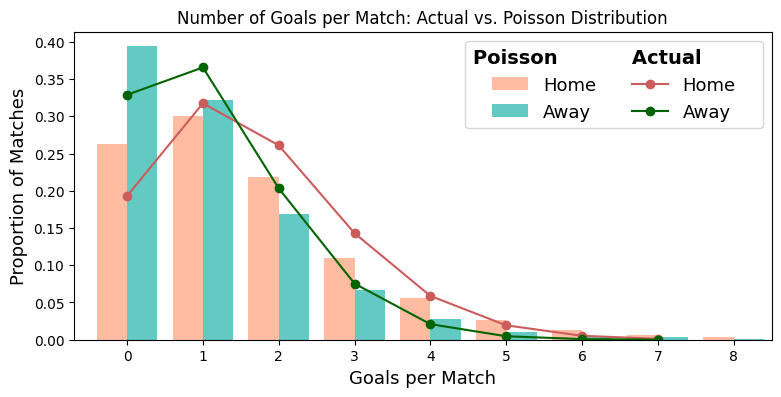

In [3]:
# mean calculation by selecting numeric columns explicitly
means = world_cup[['HomeGoals', 'AwayGoals']].mean().values
poisson_pred = np.column_stack([[poisson.pmf(i, means[j]) for i in range(8)] for j in range(2)])

fig, ax = plt.subplots(figsize=(9,4))

# Use align='left' or adjust bins to seamlessly align the histogram bars with integers
plt.hist(world_cup[['HomeGoals', 'AwayGoals']].values, bins=np.arange(10)-0.5,
         alpha=0.7, label=['Home', 'Away'], density=True, color=["#FFA07A", "#20B2AA"])

# Add lines for the Poisson distributions centered at integer values (0 to 7)
pois1, = plt.plot(range(8), poisson_pred[:,0],
                  linestyle='-', marker='o', label="Home", color='#CD5C5C')
pois2, = plt.plot(range(8), poisson_pred[:,1],
                  linestyle='-', marker='o', label="Away", color='#006400')

leg = plt.legend(loc='upper right', fontsize=13, ncol=2)
leg.set_title("Poisson           Actual        ", prop={'size':'14', 'weight':'bold'})

# Aligning x-ticks perfectly with goals integers
plt.xticks(range(9))
plt.xlim(-0.7, 8.5)
plt.xlabel("Goals per Match", size=13)
plt.ylabel("Proportion of Matches", size=13)
plt.title("Number of Goals per Match: Actual vs. Poisson Distribution")

plt.show()

We can use this statistical model to estimate the probability of specfic events.

$$
\begin{align*}
P(\geq 2|Home) &= P(2|Home) + P(3|Home) + ...\\
        &= 0.22 + 0.11 + ...\\
        &= 0.33
\end{align*}
$$

The probability of a draw is simply the sum of the events where the two teams score the same amount of goals.

$$
\begin{align*}
P(Draw) &= P(0|Home) \times P(0|Away) + P(1|Home) \times P(1|Away) + ...\\
        &= 0.26 \times 0.39 + 0.3 \times 0.32 + ...\\
        &= 0.1974
\end{align*}
$$

Note that we consider the number of goals scored by each team to be independent events (i.e. P(A n B) = P(A) P(B)). The difference of two Poisson distribution is actually called a [Skellam distribution](https://en.wikipedia.org/wiki/Skellam_distribution). So we can calculate the probability of a draw by inputting the mean goal values into this distribution.

In [4]:
# Calculate the mean by selecting the goal columns explicitly by name
means = world_cup[['HomeGoals', 'AwayGoals']].mean()

# pass the explicit column means into the Skellam PMF
# Skellam distribution models the difference between two independent Poisson distributions (Home - Away = 0 for a draw)
prob_draw = skellam.pmf(0, means['HomeGoals'], means['AwayGoals'])

print(f"Probability of a draw: {prob_draw:.4f}")

Probability of a draw: 0.2449


In [5]:
# Calculate the mean by selecting the goal columns explicitly by name
means = world_cup[['HomeGoals', 'AwayGoals']].mean()

# Pass the explicit column means into the Skellam PMF
# x=1 calculates the exact probability of HomeGoals - AwayGoals = 1
prob_home_win_by_1 = skellam.pmf(1, means['HomeGoals'], means['AwayGoals'])

print(f"Probability of Home Team winning by exactly 1 goal: {prob_home_win_by_1:.4f}")

Probability of Home Team winning by exactly 1 goal: 0.2339


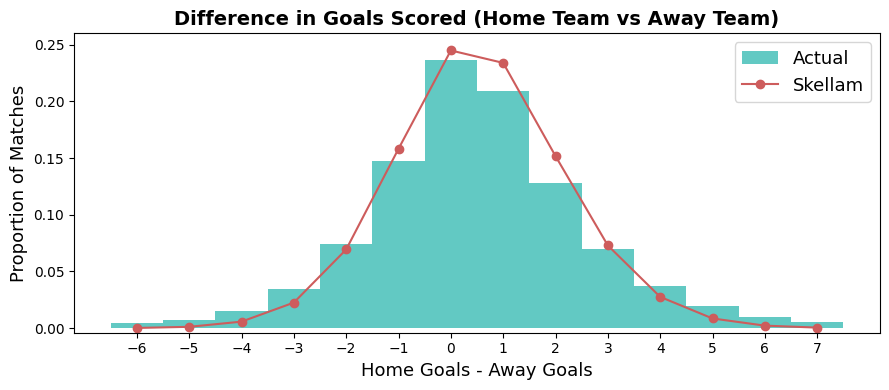

In [6]:

# Calculate column means explicitly by name to avoid Pandas TypeErrors
home_mean = world_cup['HomeGoals'].mean()
away_mean = world_cup['AwayGoals'].mean()

# Define the integer range of goal differences to evaluate (-6 to 7)
goal_diff_range = range(-6, 8)

# Calculate Skellam probabilities
skellam_pred = [skellam.pmf(i, home_mean, away_mean) for i in goal_diff_range]

fig, ax = plt.subplots(figsize=(9, 4))

# Calculate the actual goal differences as a 1D Series
actual_diffs = world_cup['HomeGoals'] - world_cup['AwayGoals']

# Center the histogram bins exactly on the integers by shifting edges by -0.5
bins = np.arange(-6, 9) - 0.5
plt.hist(actual_diffs, bins=bins, alpha=0.7, label='Actual', density=True, color='#20B2AA')

# Plot Skellam directly on the integer coordinates (no i+0.5 shift needed)
plt.plot(list(goal_diff_range), skellam_pred, linestyle='-', marker='o', label="Skellam", color='#CD5C5C')

# Formatting updates
plt.legend(loc='upper right', fontsize=13)
plt.xticks(list(goal_diff_range))  # Ticks line up perfectly with integers now
plt.xlabel("Home Goals - Away Goals", size=13)
plt.ylabel("Proportion of Matches", size=13)
plt.title("Difference in Goals Scored (Home Team vs Away Team)", size=14, fontweight='bold')
plt.ylim([-0.004, 0.26])
plt.tight_layout()

plt.show()

So, hopefully you can see how we can adapt this approach to model specific matches. We just need to know the average number of goals scored by each team and feed this data into a Poisson model. Let's have a look at the distribution of goals scored by Spain and Belgium

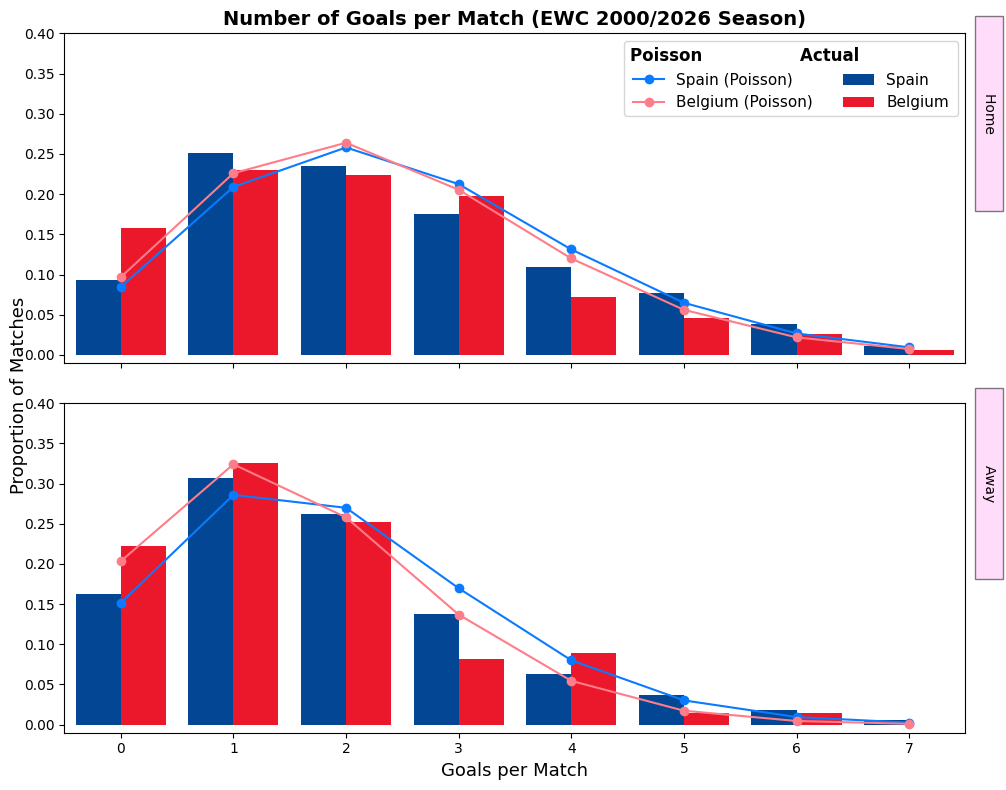

In [11]:
# Set up the subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 1. FIX: Use single brackets to get clean 1D Series for value_counts
Ger_home = world_cup[world_cup['HomeTeam']=='Spain']['HomeGoals'].value_counts(normalize=True)
Chi_home = world_cup[world_cup['HomeTeam']=='Belgium']['HomeGoals'].value_counts(normalize=True)
Ger_away = world_cup[world_cup['AwayTeam']=='Spain']['AwayGoals'].value_counts(normalize=True)
Chi_away = world_cup[world_cup['AwayTeam']=='Belgium']['AwayGoals'].value_counts(normalize=True)

# 2. FIX: Simplify lambda mean goals calculations using native .mean()
Ger_home_pois = [poisson.pmf(i, world_cup[world_cup['HomeTeam']=='Spain']['HomeGoals'].mean()) for i in range(8)]
Chi_home_pois = [poisson.pmf(i, world_cup[world_cup['HomeTeam']=='Belgium']['HomeGoals'].mean()) for i in range(8)]
Ger_away_pois = [poisson.pmf(i, world_cup[world_cup['AwayTeam']=='Spain']['AwayGoals'].mean()) for i in range(8)]
Chi_away_pois = [poisson.pmf(i, world_cup[world_cup['AwayTeam']=='Belgium']['AwayGoals'].mean()) for i in range(8)]

# --- Plot 1: HOME ---
# Adjusted widths to (-0.2 and +0.2) so bars sit perfectly symmetrical side-by-side
ax1.bar(Ger_home.index - 0.2, Ger_home.values, width=0.4, color="#034694", label="Spain")
ax1.bar(Chi_home.index + 0.2, Chi_home.values, width=0.4, color="#EB172B", label="Belgium")

ax1.plot(range(8), Ger_home_pois, linestyle='-', marker='o', label="Spain (Poisson)", color="#0a7bff")
ax1.plot(range(8), Chi_home_pois, linestyle='-', marker='o', label="Belgium (Poisson)", color="#ff7c89")

leg = ax1.legend(loc='upper right', fontsize=11, ncol=2)
leg.set_title("Poisson                 Actual                ", prop={'size': '12', 'weight': 'bold'})
ax1.set_xlim([-0.5, 7.5])
ax1.set_ylim([-0.01, 0.4])

# Replaced deprecated set_xticklabels([]) with modern tick_params to hide top labels safely
ax1.tick_params(labelbottom=False)

# --- Plot 2: AWAY ---
ax2.bar(Ger_away.index - 0.2, Ger_away.values, width=0.4, color="#034694", label="Spain")
ax2.bar(Chi_away.index + 0.2, Chi_away.values, width=0.4, color="#EB172B", label="Belgium")

ax2.plot(range(8), Ger_away_pois, linestyle='-', marker='o', label="Spain (Poisson)", color="#0a7bff")
ax2.plot(range(8), Chi_away_pois, linestyle='-', marker='o', label="Belgium (Poisson)", color="#ff7c89")
ax2.set_xlim([-0.5, 7.5])
ax2.set_ylim([-0.01, 0.4])

# Facet Labels (Ggplot2 style side-banners)
# Adjusted the Y position to 0.3 so they sit centered in the subplots
ax1.text(7.65, 0.3, '                Home                ', rotation=-90,
         bbox={'facecolor': '#ffbcf6', 'alpha': 0.5, 'pad': 5}, va='center')
ax2.text(7.65, 0.3, '                Away                ', rotation=-90,
         bbox={'facecolor': '#ffbcf6', 'alpha': 0.5, 'pad': 5}, va='center')

# Axis Titles and Overall Labels
ax1.set_title("Number of Goals per Match (EWC 2000/2026 Season)", size=14, fontweight='bold')
ax2.set_xlabel("Goals per Match", size=13)

# Replaced unstable manual text positioning with a clean global figure label
fig.text(0.01, 0.5, 'Proportion of Matches', rotation=90, size=13, va='center', ha='center')

plt.tight_layout()
plt.show()

# Turning a Poisson into a Machine Learning Representation


---

## Deriving the GLM Loss Function

Given your original equation for a single observation $x$ with an expected rate of occurrence $\lambda$:

$$P(x | \lambda) = \frac{e^{-\lambda} \lambda^x}{x!}$$


Transforming into the Natural Logarithm ($\ln$) Function:
$$\ln P(x | \lambda) = \ln\left(e^{-\lambda}\right) + \ln\left(\lambda^x\right) - \ln(x!)$$


Now, we get the simplified log-likelihood expression:
$$\ell(\lambda) = -\lambda + x \ln(\lambda) - \ln(x!)$$


Additionally, because the term $\ln(x!)$ depends purely on the actual data points ($x$) and does not contain the parameter $\lambda$ that we want to optimize, it acts as a constant. Dropping this constant term leaves us with the standard loss function.


## Building A Model

You should now be convinced that the number of goals scored by each team can be approximated by a Poisson distribution. Due to a relatively sample size, the accuracy of this approximation can vary significantly (especially earlier in the season when teams have played fewer games). Similar to before, we could now calculate the probability of various events in this World Cup match. But rather than treat each match separately, we'll build a more general Poisson regression model with the consideration of both home and away ([what is that?](https://en.wikipedia.org/wiki/Poisson_regression)).

We can further formulate the model in mathematical terms:
$$
P\left(X_{i,j} = x, Y_{j,i} = y \right) = \frac{e^{-\lambda} \lambda^x }{x!} \frac{e^{-\mu} \mu^y }{y!}
\\ \text{where } \quad \lambda = \alpha_i \beta_j \gamma \quad \mu = \alpha_j \beta_i
$$

In this equation, $i$ and $j$ refer to the home and away teams, respectively; $\alpha$ and $\beta$ denote each team's attack and defensive strength, respectively, while $\gamma$ represents the home advantage factor. So, we need to calculate $\alpha$ and $\beta$ for each team, as well as $\gamma$ (the home field advantage term- it's the same value for every team).

Since World Cup does not have 'home' advantage for most of the team, we are going to neglect the $\gamma$.



In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Clean the initial dataset
world_cup['HomeGoals'] = pd.to_numeric(world_cup['HomeGoals'], errors='coerce')
world_cup['AwayGoals'] = pd.to_numeric(world_cup['AwayGoals'], errors='coerce')
world_cup = world_cup.dropna(subset=['HomeGoals', 'AwayGoals', 'HomeTeam', 'AwayTeam'])

# 2. Reshape the DataFrame
goal_model_data = pd.concat([
    world_cup[['HomeTeam', 'AwayTeam', 'HomeGoals']].assign(home=1).rename(
        columns={'HomeTeam': 'team', 'AwayTeam': 'opponent', 'HomeGoals': 'goals'}),
    world_cup[['AwayTeam', 'HomeTeam', 'AwayGoals']].assign(home=0).rename(
        columns={'AwayTeam': 'team', 'HomeTeam': 'opponent', 'AwayGoals': 'goals'})
])

# Ensure goals are integers and drop any remaining NaN/Inf values
goal_model_data['goals'] = goal_model_data['goals'].astype(int)
goal_model_data = goal_model_data[np.isfinite(goal_model_data['goals'])]

# Drop teams with too few matches (prevents perfect separation)
# Teams with 1 or 2 matches can easily cause the exponent to overflow
team_counts = goal_model_data['team'].value_counts()
valid_teams = team_counts[team_counts >= 3].index
goal_model_data = goal_model_data[goal_model_data['team'].isin(valid_teams) & goal_model_data['opponent'].isin(valid_teams)]

# Define the categorical formula
formula = "goals ~ home + C(team) + C(opponent)"

# Use a robust optimization technique to handle convergence safely
try:
    # Attempt regular fitting
    poisson_model = smf.glm(formula=formula, data=goal_model_data, family=sm.families.Poisson()).fit()
except ValueError:
    print("Standard solver failed due to mathematical instability. Switching to regularized fit...")
    # fit_regularized applies a tiny penalty to prevent coefficients from sliding to infinity
    poisson_model = smf.glm(formula=formula, data=goal_model_data, family=sm.families.Poisson()).fit_regularized(alpha=1e-4)

# Print the summary results
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                50694
Model:                            GLM   Df Residuals:                    50086
Model Family:                 Poisson   Df Model:                          607
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -71137.
Date:                Fri, 10 Jul 2026   Deviance:                       57654.
Time:                        03:51:47   Pearson chi2:                 5.25e+04
No. Iterations:                    22   Pseudo R-squ. (CS):             0.3992
Covariance Type:            nonrobust                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [13]:
poisson_model.predict(pd.DataFrame(data={'team': 'Spain', 'opponent': 'Belgium',
                                       'home':0},index=[1]))

,0
1,1.51935


In [14]:
poisson_model.predict(pd.DataFrame(data={'team': 'Belgium', 'opponent': 'Spain',
                                       'home':0},index=[1]))

,0
1,0.842762


As an example, Spain (without home avantage) would be expected to score 1.519 goals against Belgium, while their opponents would get about 0.842 goals on average (I'm using the terms average and expected interchangeably). As each team is treated independently, we can construct a match score probability matrix.

In [18]:
def simulate_match(foot_model, homeTeam, awayTeam, max_goals=10):
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam,
                                                            'opponent': awayTeam,'home':0},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam,
                                                            'opponent': homeTeam,'home':0},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return(np.outer(np.array(team_pred[0]), np.array(team_pred[1])))
ars_sou = simulate_match(poisson_model, 'Spain', 'Belgium', max_goals=10)
print(ars_sou[0:5, 0:5])

[[0.09422105 0.07940592 0.03346015 0.00939965 0.00198042]
 [0.14315472 0.12064536 0.05083767 0.01428135 0.00300895]
 [0.10875103 0.09165124 0.03862009 0.01084918 0.00228582]
 [0.05507695 0.04641676 0.01955914 0.00549457 0.00115765]
 [0.02092028 0.01763082 0.00742929 0.00208704 0.00043972]]


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import poisson
from ipywidgets import interact, IntSlider

# 1. Code 2 Simulation Function
def simulate_match(foot_model, homeTeam, awayTeam, max_goals=5):  # Changed default to 5
    home_goals_avg = foot_model.predict(pd.DataFrame(data={'team': homeTeam,
                                                            'opponent': awayTeam, 'home': 0},
                                                      index=[1])).values[0]
    away_goals_avg = foot_model.predict(pd.DataFrame(data={'team': awayTeam,
                                                            'opponent': homeTeam, 'home': 0},
                                                      index=[1])).values[0]
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [home_goals_avg, away_goals_avg]]
    return (np.outer(np.array(team_pred[0]), np.array(team_pred[1])))

# Generate the 6x6 matrix (0 to 5 goals) for Spain vs. Belgium
ars_sou = simulate_match(poisson_model, 'Spain', 'Belgium', max_goals=5)
matn = len(ars_sou) # Will dynamically be 6

# 2. Plotting Function Optimized for max_goals=5
def matrix_gif(matrix, colour_matrix, colour_map, subtitle="", heatmap=False, alpha=0.8):
    fig, ax1 = plt.subplots(1, figsize=(6, 6))

    if heatmap:
        ax1.matshow(matrix, alpha=alpha)
    else:
        ax1.matshow(colour_matrix, cmap=colour_map, alpha=alpha)

    ax1.tick_params(axis='both', which='both', length=0)
    ax1.grid(which='major', axis='both', linestyle='')
    ax1.set_xlabel('Away Team Goals', fontsize=12)
    ax1.set_ylabel('Home Team Goals', fontsize=12)
    ax1.xaxis.set_label_position('top')

    # Grid ticks matched to 6x6 sizing
    nrows, ncols = matrix.shape
    ax1.set_xticks(range(ncols))
    ax1.set_yticks(range(nrows))

    # Overlay text probabilities (Increased text size to 11 for better readability)
    for i in range(nrows):
        for j in range(ncols):
            c = matrix[i][j]
            is_highlighted = (not heatmap and colour_matrix[i][j] > 0)
            ax1.text(j, i, f"{c:.4f}", va='center', ha='center', size=11,
                     fontweight='bold' if is_highlighted else 'normal')

    plt.figtext(0.5, 0.02, subtitle, horizontalalignment='center',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

# 3. Binary Masks Automatically Scaling to matn=6
frames = [
    (ars_sou, 'w', "Match Score Probability Matrix", True),
    (np.zeros((matn, matn)), 'w', 'Match Score Probability Matrix', False),
    (np.tril(np.ones((matn, matn)), -1), '#04f5ff', 'Home Win', False),
    (np.triu(np.ones((matn, matn)), 1), '#00ff85', 'Away Win', False),
    (np.eye(matn), '#e90052', 'Draw', False),
    ((np.fromfunction(lambda i, j: i + j > 2.5, (matn, matn))).astype(int), '#EAF205', 'Over 2.5 goals', False)
]

# 4. Interactive GIF-Alike Player
def play_gif(frame_index):
    mat, colour, subtitle, is_heatmap = frames[frame_index]
    cmap_custom = ListedColormap(['w', colour]) if not is_heatmap else ListedColormap(['w'])

    matrix_gif(ars_sou, mat, cmap_custom, heatmap=is_heatmap, alpha=0.6, subtitle=subtitle)
    plt.show()

# Run the slider control
interact(play_gif, frame_index=IntSlider(min=0, max=len(frames)-1, step=1, value=0, description='Frame:'));

interactive(children=(IntSlider(value=0, description='Frame:', max=5), Output()), _dom_classes=('widget-intera…

In [31]:
# 1. Generate the probability matrix
matrix = simulate_match(poisson_model, 'Spain', 'Belgium', max_goals=5)
matn = len(matrix)

# 2. Define the mathematical masks for each outcome
# Home wins are represented by the lower triangle (excluding the diagonal)
home_win_mask = np.tril(np.ones((matn, matn)), -1)

# Away wins are represented by the upper triangle (excluding the diagonal)
away_win_mask = np.triu(np.ones((matn, matn)), 1)

# Draws are represented by the main diagonal
draw_mask = np.diag([1] * matn)

# Over 2.5 goals are cells where the row index (home goals) + column index (away goals) >= 3
over_2_5_mask = np.array([1 if i + j >= 3 else 0 for i in range(matn) for j in range(matn)]).reshape(matn, matn)


# 3. Calculate probabilities by element-wise multiplication and summing the matrix
prob_home_win = np.sum(matrix * home_win_mask)
prob_away_win = np.sum(matrix * away_win_mask)
prob_draw     = np.sum(matrix * draw_mask)
prob_over_2_5 = np.sum(matrix * over_2_5_mask)


# 4. Display the results
print(f"--- Match Outcome Probabilities ---")
print(f"Home Win Probability: {prob_home_win * 100:.2f}%")
print(f"Away Win Probability: {prob_away_win * 100:.2f}%")
print(f"Draw Probability:     {prob_draw * 100:.2f}%")
print(f"Over 2.5 Goals Prob:  {prob_over_2_5 * 100:.2f}%")

# Sanity Check: Home + Away + Draw should equal ~100% (or slightly less if max_goals is too low)
total_sum = prob_home_win + prob_away_win + prob_draw
print(f"\nTotal Matrix Sum Coverage: {total_sum * 100:.2f}%")

--- Match Outcome Probabilities ---
Home Win Probability: 52.74%
Away Win Probability: 20.82%
Draw Probability:     25.94%
Over 2.5 Goals Prob:  41.54%

Total Matrix Sum Coverage: 99.50%


##Sports Betting/Trading

Hong Kong Jockey Club (HKJC) is one of the traditional betting exchanges, you bet against HKJC (with HKJC taking a Margin from each bet type). It acts as a sort of stock market for sports events. And, like a stock market, due to the efficient market hypothesis, the prices available at HKJC reflect the true price/odds of those events happening (in theory anyway). Below, I’ve posted a screenshot of the HKJC exchange on Friday 10 Jul 2026 (a few hours before those matches started).


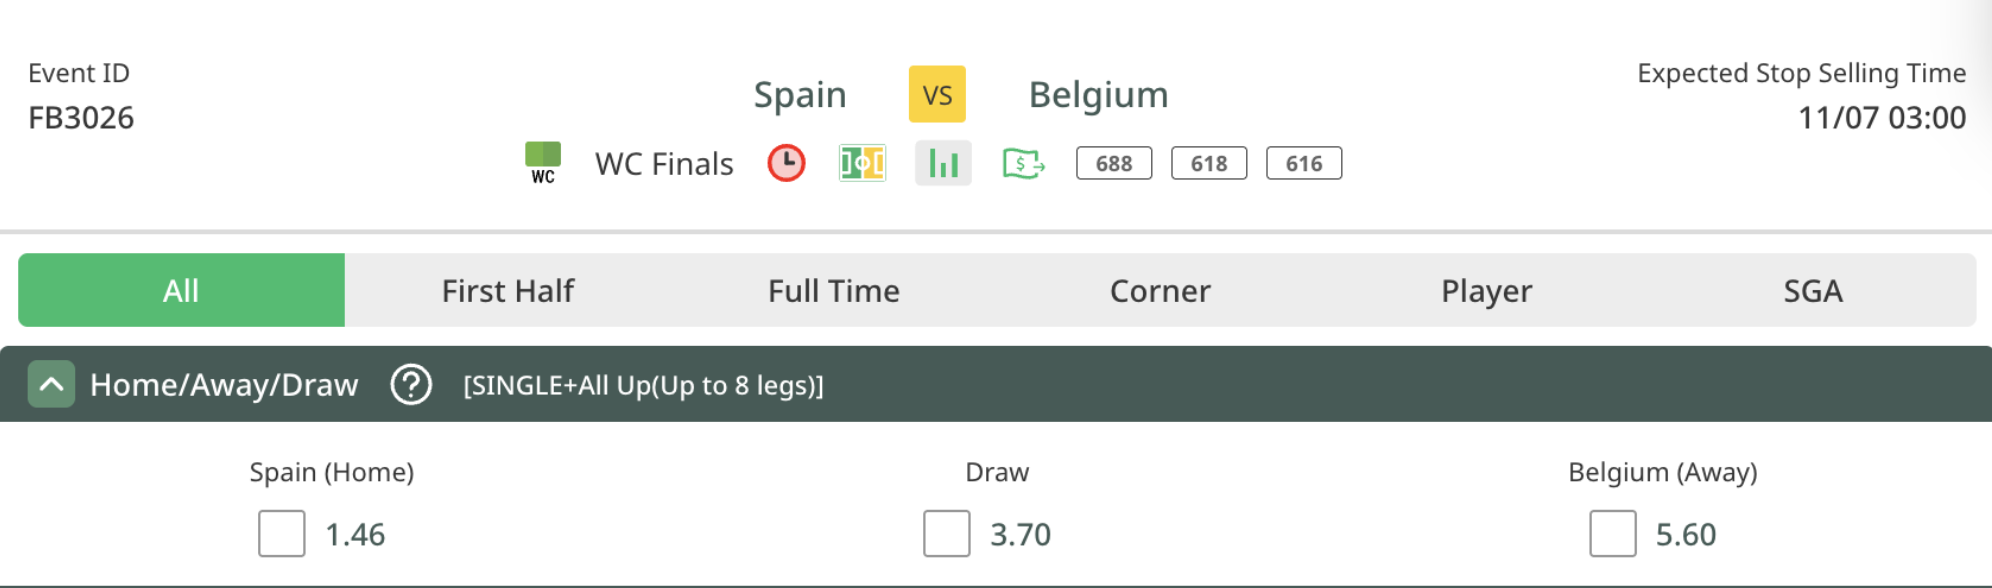

##Home Away Draw Bet Type

So, we have our model probabilities and (if we trust the HKJC) we know the true probabilities of each event happening. Ideally, our model would identify situations the market has underestimated the chances of an event occurring. For example, in a Spain vs Belgium game, imagine if you were offered 5.6 HKD for every 1 HKD wagered, if you guessed correctly. The HKJC implied probability is 0.1785, but our ML model would return a probability of 0.2082. The odds returned by our model and the Betfair exchange are compared in the table below.

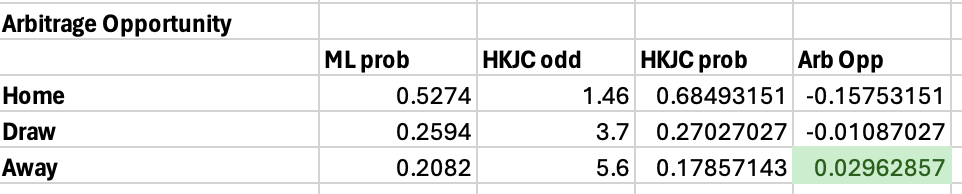

##Correct Score Bet Type

By applying the same logic, we can calculate the underestimated chances of the correct score as all the match outcomes should be mutually exclusive. By comparing our ML probability matrix with the HKJC probability, we shall get the arbitrage opportunity.

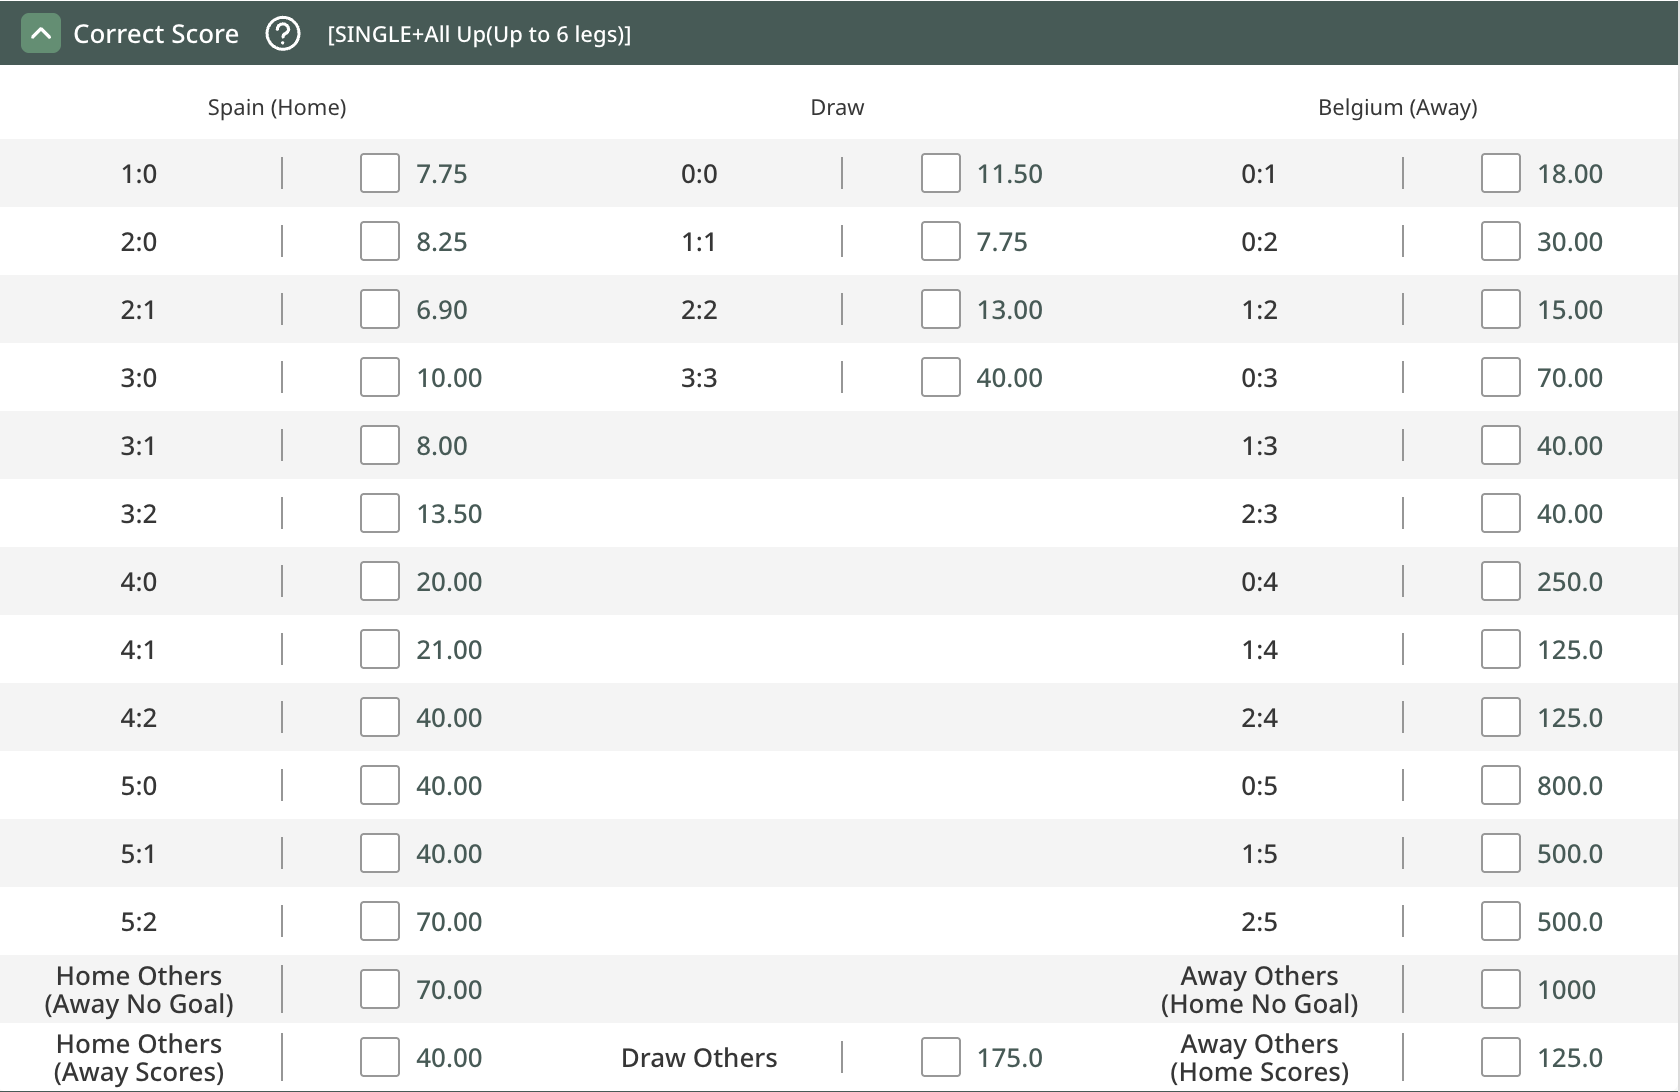

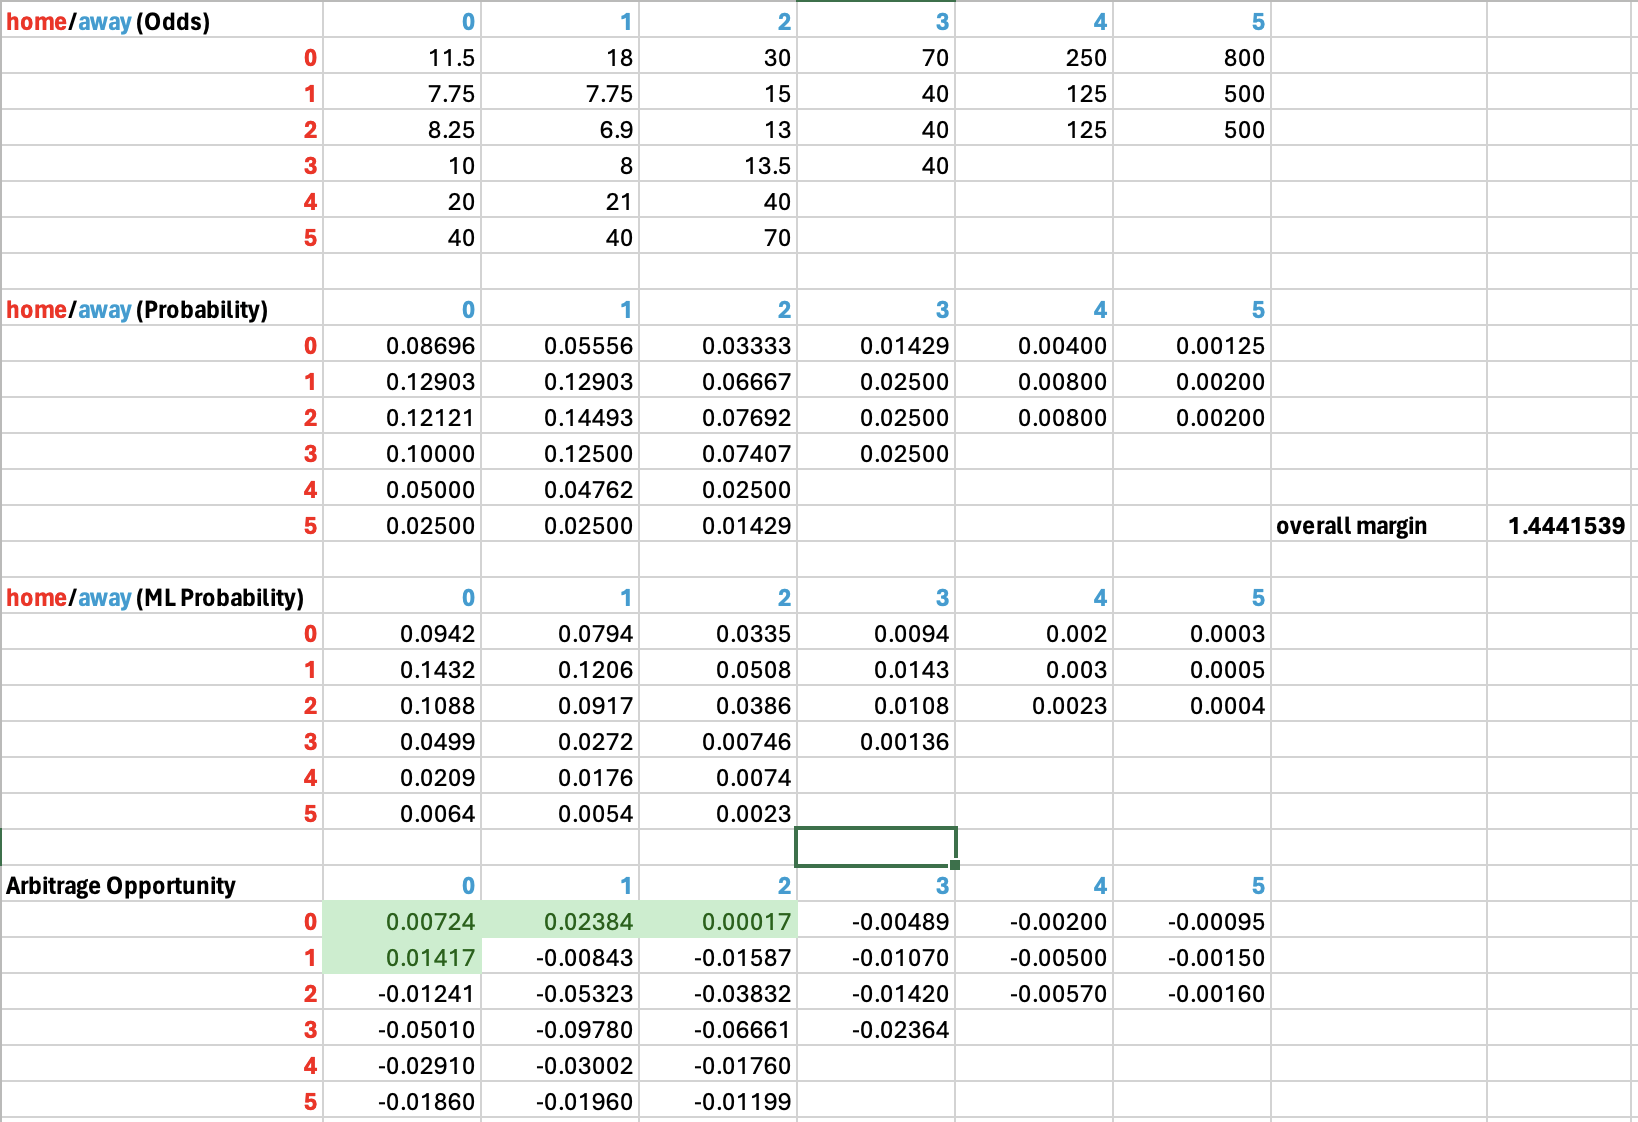

##Appendix

Handicap Bet Type, which is another representation of the Home Away Draw bet type. From the get go, there is an extra offset between the goal to-be-scored on both teams. Let's take a look on the example below.

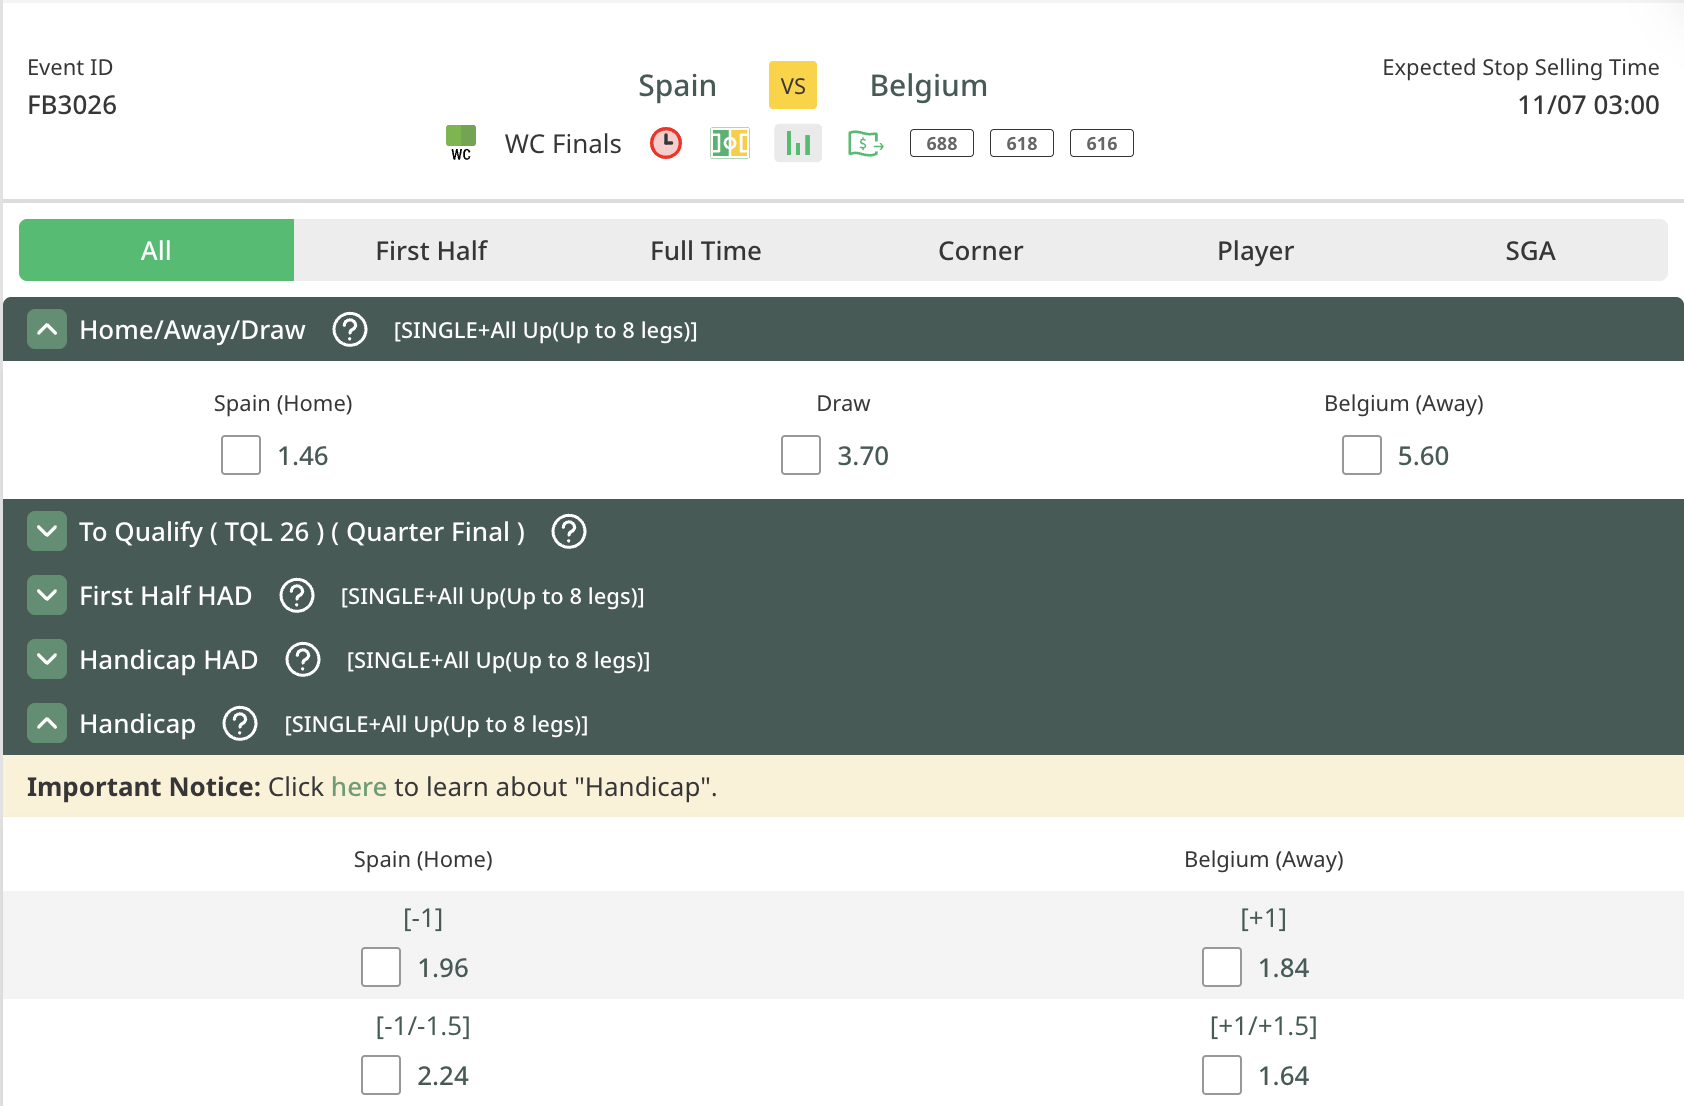

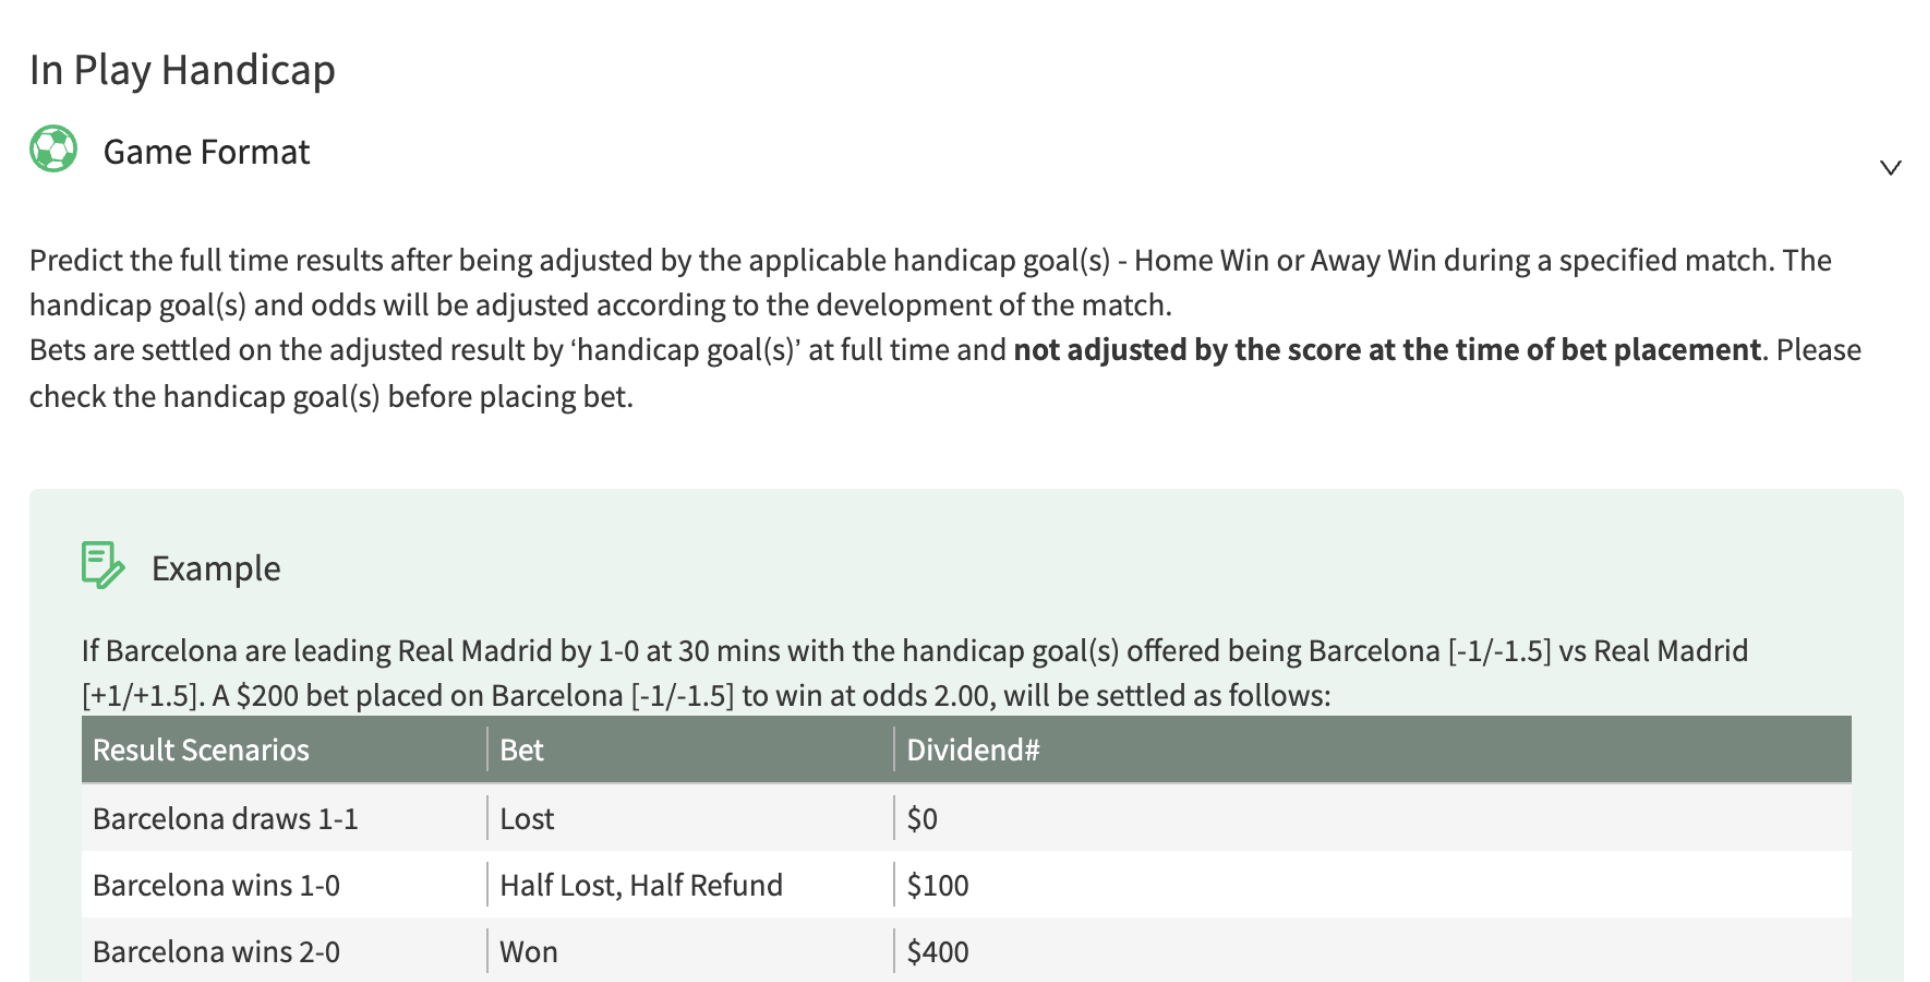